# Model 7 — Hybrid Recommendation Engine

Ranks all portal players for a given program and returns the **top 50 candidates** using a weighted hybrid of three signals:

| Signal | Weight | Method |
|---|---|---|
| Collaborative filtering | 30% | Truncated SVD on historical program × player recruitment matrix |
| Content-based filtering | 30% | Cosine similarity between player feature vector and program's ideal profile |
| Fit scores | 40% | Weighted composite of `gap_match`, `scheme_fit`, `role_fit`, `program_fit` |

**Hard filter** applied before ranking: position eligibility (`positions_needed`).

All inputs in this notebook are **synthetic**. Swap the `generate_synthetic_players()` and `generate_mock_recruitment_matrix()` functions with real DB/CSV loads when production data is ready.

For the second stage (top 50 -> 10), team priority and/or team ranking/success rate can be applied

In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics.pairwise import cosine_similarity
from scipy.sparse.linalg import svds
from scipy.sparse import csr_matrix
import warnings

warnings.filterwarnings('ignore')
np.random.seed(42)

sns.set_style('whitegrid')
plt.rcParams.update({'figure.dpi': 100, 'font.size': 11})

print('Libraries loaded')

Libraries loaded


## 1. Synthetic Data Generation

Generates 200 portal players with realistic, position-stratified stat distributions (means anchored to the league benchmarks computed in `gap_matching.ipynb`) and four pre-computed fit sub-scores.

One program dict defines the recruiting context: which positions are needed, which archetypes are targeted, and how to weight the four fit dimensions.

**To swap in real data:** replace `generate_synthetic_players()` with a DataFrame loaded from `player_season_stats` + `player_team_fit_scores`, and replace `program` with a lookup from the programs table.

In [29]:
POSITIONS = ['PG', 'SG', 'SF', 'PF', 'C']

ARCHETYPES = [
    'Lead Scoring Playmaker',
    'High-Usage Frontcourt Creator',
    'Skilled Stretch Forward',
    'Post Scoring Big',
    'Two-Way Perimeter Guard',
    'Pressure Connector Guard',
    'Active Connector Forward',
    'Two-Way Spacing Wing',
    'Interior Star Big',
]

# Primary archetypes per position (from player_clustering.ipynb labels)
ARCHETYPE_AFFINITY = {
    'PG': ['Lead Scoring Playmaker', 'Pressure Connector Guard', 'Two-Way Perimeter Guard'],
    'SG': ['Two-Way Perimeter Guard', 'Two-Way Spacing Wing', 'Pressure Connector Guard'],
    'SF': ['Two-Way Spacing Wing', 'Skilled Stretch Forward', 'Active Connector Forward'],
    'PF': ['High-Usage Frontcourt Creator', 'Skilled Stretch Forward', 'Active Connector Forward'],
    'C':  ['Post Scoring Big', 'Interior Star Big', 'High-Usage Frontcourt Creator'],
}

# (mean, std) per position — anchored to 2026 league benchmarks from gap_matching.ipynb
# Portal players skew slightly above average, so means are bumped ~10-15%
POS_STAT_PARAMS = {
    'PG': {'ppg': (13.0, 4.5), 'rpg': (3.0, 1.5), 'apg': (4.5, 2.0),
           'per': (16.5, 4.0), 'ts_pct': (0.53, 0.05), 'usage_rate': (22.0, 4.0), 'three_pt_pct': (0.34, 0.08)},
    'SG': {'ppg': (12.0, 4.0), 'rpg': (4.0, 1.5), 'apg': (2.8, 1.5),
           'per': (15.5, 4.0), 'ts_pct': (0.54, 0.05), 'usage_rate': (20.0, 4.0), 'three_pt_pct': (0.36, 0.08)},
    'SF': {'ppg': (11.0, 3.5), 'rpg': (5.0, 2.0), 'apg': (2.5, 1.5),
           'per': (14.5, 4.0), 'ts_pct': (0.54, 0.05), 'usage_rate': (19.0, 4.0), 'three_pt_pct': (0.32, 0.09)},
    'PF': {'ppg': (10.5, 3.5), 'rpg': (6.5, 2.0), 'apg': (2.0, 1.2),
           'per': (14.5, 4.0), 'ts_pct': (0.55, 0.05), 'usage_rate': (18.0, 4.0), 'three_pt_pct': (0.26, 0.10)},
    'C':  {'ppg': (9.0,  3.0), 'rpg': (7.5, 2.0), 'apg': (1.5, 1.0),
           'per': (15.0, 4.0), 'ts_pct': (0.57, 0.05), 'usage_rate': (16.0, 3.0), 'three_pt_pct': (0.08, 0.10)},
}

STAT_COLS = ['ppg', 'rpg', 'apg', 'per', 'ts_pct', 'usage_rate', 'three_pt_pct']
FIT_COLS  = ['gap_match', 'scheme_fit', 'role_fit', 'program_fit']

# Top-level hybrid weights (must sum to 1.0)
W_COLLAB  = 0.30
W_CONTENT = 0.30
W_FIT     = 0.40

print(f'Hybrid weights: collab={W_COLLAB}, content={W_CONTENT}, fit={W_FIT} (sum={W_COLLAB+W_CONTENT+W_FIT})')

Hybrid weights: collab=0.3, content=0.3, fit=0.4 (sum=1.0)


In [30]:
def generate_synthetic_players(n: int = 200, seed: int = 42) -> pd.DataFrame:
    """Generate n synthetic portal player records with realistic stat distributions.

    Fit sub-scores (gap_match, scheme_fit, role_fit, program_fit) are correlated
    with a talent proxy (ppg + per) to mimic the real relationship between production
    and fit scores. Scatter is intentionally large to stress-test the ranking logic.

    Returns a DataFrame matching the M7 input contract (see notebook header).
    """
    rng = np.random.default_rng(seed)

    # Draw positions with realistic portal distribution (guards over-represented)
    positions = rng.choice(POSITIONS, size=n, p=[0.25, 0.25, 0.20, 0.15, 0.15])
    archetypes = np.array([rng.choice(ARCHETYPE_AFFINITY[pos]) for pos in positions])

    rows = []
    for i, (pos, arch) in enumerate(zip(positions, archetypes)):
        params = POS_STAT_PARAMS[pos]
        row = {'player_id': i + 1, 'name': f'Player_{i+1:03d}', 'position': pos, 'archetype': arch}

        for stat, (mu, sigma) in params.items():
            row[stat] = float(np.clip(rng.normal(mu, sigma), 0, None))

        # Fit scores: loosely correlated with talent, but noisy (real fit scoring is model-derived)
        talent = (row['ppg'] + row['per']) / 2
        base   = float(np.clip(talent * 2.2 + rng.normal(20, 15), 0, 100))

        row['gap_match']   = float(np.clip(rng.normal(base * 0.70, 22), 0, 100))
        row['scheme_fit']  = float(np.clip(rng.normal(base * 0.90, 10), 0, 100))
        row['role_fit']    = float(np.clip(rng.normal(base * 0.85, 13), 0, 100))
        row['program_fit'] = float(np.clip(rng.normal(base * 0.80, 16), 0, 100))

        rows.append(row)

    df = pd.DataFrame(rows)
    df['ts_pct']       = df['ts_pct'].clip(0.0, 1.0)
    df['three_pt_pct'] = df['three_pt_pct'].clip(0.0, 1.0)

    print(f'Generated {len(df)} players')
    print(f'  Position breakdown: {df["position"].value_counts().to_dict()}')
    print(f'  Archetype coverage: {df["archetype"].nunique()} of {len(ARCHETYPES)} archetypes')
    print()
    return df


players = generate_synthetic_players(n=200, seed=42)
players[['player_id', 'name', 'position', 'archetype'] + STAT_COLS + FIT_COLS].head(6)

Generated 200 players
  Position breakdown: {'SG': 54, 'PG': 50, 'SF': 38, 'PF': 33, 'C': 25}
  Archetype coverage: 9 of 9 archetypes



,player_id,name,position,archetype,ppg,rpg,apg,per,ts_pct,usage_rate,three_pt_pct,gap_match,scheme_fit,role_fit,program_fit
0,1,Player_001,PF,Active Connector Forward,9.477401,6.293023,1.697627,15.110250,0.623575,7.733366,0.236315,41.297739,41.005546,19.402604,45.003210
1,2,Player_002,SG,Pressure Connector Guard,18.909401,1.699208,4.095742,14.185899,0.536934,15.788406,0.333244,65.952265,85.638065,79.826029,67.749786
2,3,Player_003,C,Post Scoring Big,14.231804,8.377986,2.327988,13.813716,0.573327,13.907729,0.178958,40.434570,27.951455,43.425402,38.554318
3,4,Player_004,SF,Active Connector Forward,17.372262,6.461549,0.141940,14.232187,0.481400,16.926881,0.456011,29.653061,47.757937,55.104883,31.997358
4,5,Player_005,PG,Pressure Connector Guard,9.979869,3.468014,6.810624,18.935046,0.415436,23.217467,0.345763,76.166945,31.580902,41.628202,55.866309
5,6,Player_006,C,Interior Star Big,4.255217,10.451898,1.868357,18.386336,0.541453,18.441291,0.186847,39.036034,46.262423,29.915558,36.358644


In [31]:
# Program context — one dict per recruiting cycle.
# In production this comes from the programs table keyed by program_id + season.
program = {
    'program_id': 'UCB_2026',
    'positions_needed': ['PG', 'SF'],        # hard filter: only these positions ranked
    'target_archetypes': [
        'Lead Scoring Playmaker',
        'Two-Way Spacing Wing',
    ],
    'importance_weights': {                  # must sum to 1.0; program-adjustable
        'gap_match':   0.20,
        'scheme_fit':  0.30,
        'role_fit':    0.25,
        'program_fit': 0.25,
    },
}

w = program['importance_weights']
print(f"Program : {program['program_id']}")
print(f"Positions needed  : {program['positions_needed']}")
print(f"Target archetypes : {program['target_archetypes']}")
print(f"Fit weights       : gap={w['gap_match']}, scheme={w['scheme_fit']}, role={w['role_fit']}, program={w['program_fit']}")
print(f"Weights sum       : {sum(w.values()):.2f}")

Program : UCB_2026
Positions needed  : ['PG', 'SF']
Target archetypes : ['Lead Scoring Playmaker', 'Two-Way Spacing Wing']
Fit weights       : gap=0.2, scheme=0.3, role=0.25, program=0.25
Weights sum       : 1.00


## 2. Feature Engineering

Builds two objects needed for content-based filtering:

1. **Player feature matrix** `(n_players × n_features)` — continuous stats normalized to [0, 1] via `MinMaxScaler`, concatenated with a 5-column position one-hot. Normalization ensures no single stat dominates the cosine similarity calculation by scale alone.

2. **Program profile vector** — the mean feature vector of all players whose archetype matches `program['target_archetypes']`. This represents the program's "ideal" player in feature space. Falls back to the full-population mean if no archetype matches exist.

In [32]:
def build_player_feature_vectors(
    players_df: pd.DataFrame,
    stat_cols: list = STAT_COLS,
) -> tuple:
    """Normalize player stats to [0,1] and append position one-hot encoding.

    Returns
    -------
    feature_matrix : ndarray (n_players, n_stat_cols + 5)
    feature_names  : list[str]
    scaler         : fitted MinMaxScaler — reuse on any new player to score later
    """
    scaler = MinMaxScaler()
    stats_scaled = scaler.fit_transform(players_df[stat_cols].values)

    # One-hot for positions; reindex ensures consistent column order even if a
    # position is absent from the current player pool
    pos_dummies = (
        pd.get_dummies(players_df['position'], prefix='pos')
          .reindex(columns=[f'pos_{p}' for p in POSITIONS], fill_value=0)
          .values.astype(float)
    )

    feature_matrix = np.hstack([stats_scaled, pos_dummies])
    feature_names  = stat_cols + [f'pos_{p}' for p in POSITIONS]

    print(f'Feature matrix : {feature_matrix.shape}  ({len(stat_cols)} stats + {len(POSITIONS)} pos one-hot)')
    print(f'Features       : {feature_names}')
    return feature_matrix, feature_names, scaler


feature_matrix, feature_names, stat_scaler = build_player_feature_vectors(players)

Feature matrix : (200, 12)  (7 stats + 5 pos one-hot)
Features       : ['ppg', 'rpg', 'apg', 'per', 'ts_pct', 'usage_rate', 'three_pt_pct', 'pos_PG', 'pos_SG', 'pos_SF', 'pos_PF', 'pos_C']


In [33]:
def build_program_profile(
    players_df: pd.DataFrame,
    feature_matrix: np.ndarray,
    program: dict,
) -> np.ndarray:
    """Compute the program's ideal-player vector in feature space.

    In production, the profile can also be built from the program's own historical
    roster stats rather than from portal player archetypes.
    """
    mask    = players_df['archetype'].isin(program['target_archetypes']).values
    n_match = mask.sum()

    if n_match == 0:
        print('WARNING: no archetype matches — falling back to full-population mean')
        return feature_matrix.mean(axis=0)

    profile = feature_matrix[mask].mean(axis=0)
    print(f'Profile built from {n_match} players matching target archetypes')
    print(f'  Archetypes: {program["target_archetypes"]}')
    return profile


program_profile = build_program_profile(players, feature_matrix, program)
print(f'Profile shape: {program_profile.shape}')

# Visualize which features are highest in the program profile
profile_df = pd.Series(program_profile, index=feature_names).sort_values(ascending=False)
print(f'\nTop-5 profile dimensions:\n{profile_df.head().round(3).to_string()}')

Profile built from 42 players matching target archetypes
  Archetypes: ['Lead Scoring Playmaker', 'Two-Way Spacing Wing']
Profile shape: (12,)

Top-5 profile dimensions:
ppg             0.570
per             0.568
usage_rate      0.535
three_pt_pct    0.525
pos_PG          0.476


## 3. Content-Based Filtering Score

Computes **cosine similarity** between each player's feature vector and the program profile, then rescales to [0, 100].

Cosine similarity ∈ [-1, 1]. Negative values (player is statistically "opposite" to the ideal profile) are clipped to 0 — they provide no useful signal and would distort the min-max rescaling. The rescaling maps the observed [min, max] range of non-negative similarities to [0, 100] so content scores are on the same scale as fit scores.

In [34]:
def compute_content_scores(
    feature_matrix: np.ndarray,
    program_profile: np.ndarray,
) -> np.ndarray:
    """Cosine similarity between each player and the program profile, scaled to [0, 100]."""
    raw_sims = cosine_similarity(feature_matrix, program_profile.reshape(1, -1)).flatten()
    sims     = np.clip(raw_sims, 0, 1)

    lo, hi = sims.min(), sims.max()
    if hi > lo:
        scores = (sims - lo) / (hi - lo) * 100.0
    else:
        scores = np.full_like(sims, 50.0)  # degenerate case: all players identical

    print(f'Raw cosine sim  : mean={raw_sims.mean():.3f}, std={raw_sims.std():.3f}, '
          f'min={raw_sims.min():.3f}, max={raw_sims.max():.3f}')
    print(f'Content scores  : mean={scores.mean():.1f}, std={scores.std():.1f}, '
          f'min={scores.min():.1f}, max={scores.max():.1f}')
    return scores


content_scores = compute_content_scores(feature_matrix, program_profile)
players['content_score'] = content_scores

print(f'\nTop-5 by content score:')
print(players.nlargest(5, 'content_score')[['name', 'position', 'archetype', 'content_score']].to_string(index=False))

Raw cosine sim  : mean=0.767, std=0.108, min=0.463, max=0.931
Content scores  : mean=64.9, std=23.0, min=0.0, max=100.0

Top-5 by content score:
      name position                archetype  content_score
Player_155       PG  Two-Way Perimeter Guard     100.000000
Player_161       PG Pressure Connector Guard      98.892134
Player_128       PG   Lead Scoring Playmaker      98.864724
Player_153       PG  Two-Way Perimeter Guard      98.322546
Player_131       PG Pressure Connector Guard      98.318580


## 4. Collaborative Filtering Score (SVD)

Decomposes the programs × players recruitment matrix **R ≈ UΣVᵀ** using truncated SVD (k=10 latent factors). The key idea: programs that have historically recruited similar players share latent preferences. SVD extracts these patterns and uses them to predict how interested the target program would be in players it has never directly scouted.

Steps:
1. Build (or load) the recruitment matrix — rows = programs, cols = players, values = recruitment signal (0 = no contact, 1–5 = interest level)
2. Decompose with `scipy.sparse.linalg.svds` (efficient on sparse matrices)
3. Reconstruct the full matrix for row `program_idx` only: `predicted[p] = U[program_idx] · Σ · Vᵀ[:, p]`
4. Normalize to [0, 100]

**To swap in real data:** replace `generate_mock_recruitment_matrix()` with a load from the `recruitment_signals` table (when portal history is available), passing the resulting sparse matrix directly to `compute_collab_scores()`.

In [35]:
def generate_mock_recruitment_matrix(
    n_programs: int = 50,
    n_players: int = 200,
    players_df: pd.DataFrame = None,
    target_program_idx: int = 0,
    target_positions: list = None,
    seed: int = 42,
) -> np.ndarray:
    """Build a mock programs x players co-recruitment signal matrix.

    Values represent historical interest level (0 = no contact, 1-5 = increasing
    engagement). Sparse: each program scouts 15-30% of the total player pool.

    The target program gets boosted signal on players matching positions_needed,
    simulating a program that has historically prioritized those spots.
    """
    rng    = np.random.default_rng(seed)
    matrix = np.zeros((n_programs, n_players), dtype=np.float32)

    for prog_idx in range(n_programs):
        n_contacts  = int(rng.integers(30, 60))  # scout 15-30% of pool
        player_idxs = rng.choice(n_players, size=n_contacts, replace=False)
        signals     = rng.integers(1, 6, size=n_contacts).astype(float)
        matrix[prog_idx, player_idxs] = signals

    # Elevate target program's signal for position-matched players
    if players_df is not None and target_positions:
        pos_mask     = players_df['position'].isin(target_positions).values
        pos_player_idxs = np.where(pos_mask)[0]
        n_boost      = min(len(pos_player_idxs), 20)
        boost_idxs   = rng.choice(pos_player_idxs, size=n_boost, replace=False)
        boost_signal = rng.uniform(1.5, 3.0, size=n_boost)
        matrix[target_program_idx, boost_idxs] = np.clip(
            matrix[target_program_idx, boost_idxs] + boost_signal, 0, 5
        )

    sparsity = (matrix == 0).sum() / matrix.size
    print(f'Recruitment matrix : {n_programs} programs x {n_players} players')
    print(f'  Sparsity : {sparsity:.1%}  |  Non-zero entries : {(matrix > 0).sum():,}')
    print(f'  Target program (idx={target_program_idx}) has {(matrix[target_program_idx] > 0).sum()} scouted players')
    return matrix


recruitment_matrix = generate_mock_recruitment_matrix(
    n_programs=50,
    n_players=len(players),
    players_df=players,
    target_program_idx=0,
    target_positions=program['positions_needed'],
    seed=42,
)

Recruitment matrix : 50 programs x 200 players
  Sparsity : 77.3%  |  Non-zero entries : 2,270
  Target program (idx=0) has 50 scouted players


In [36]:
def compute_collab_scores(
    recruitment_matrix: np.ndarray,
    program_idx: int = 0,
    n_factors: int = 10,
) -> np.ndarray:
    """Truncated SVD collaborative filtering for a single target program.

    Decomposes R ~ U * diag(sigma) * Vt, then reconstructs predicted interest
    for program_idx across all players. Captures latent program-similarity signal:
    programs with overlapping recruitment histories share latent factor loadings
    and thus implicitly recommend each other's targets.

    n_factors=10 is a reasonable default for 50 programs; increase for larger matrices.
    """
    k = min(n_factors, min(recruitment_matrix.shape) - 1)

    U, sigma, Vt = svds(csr_matrix(recruitment_matrix.astype(np.float64)), k=k)

    # Reconstruct only the row we need — avoids materializing the full n_programs x n_players matrix
    predicted = (U[program_idx] * sigma) @ Vt  # shape: (n_players,)

    lo, hi = predicted.min(), predicted.max()
    if hi > lo:
        scores = (predicted - lo) / (hi - lo) * 100.0
    else:
        scores = np.full_like(predicted, 50.0)

    print(f'SVD: k={k} factors')
    print(f'  Singular values (largest 5): {np.sort(sigma)[::-1][:5].round(2)}')
    print(f'Collab scores : mean={scores.mean():.1f}, std={scores.std():.1f}, '
          f'min={scores.min():.1f}, max={scores.max():.1f}')
    return scores


collab_scores = compute_collab_scores(recruitment_matrix, program_idx=0, n_factors=10)
players['collab_score'] = collab_scores

print(f'\nTop-5 by collab score:')
print(players.nlargest(5, 'collab_score')[['name', 'position', 'archetype', 'collab_score']].to_string(index=False))

SVD: k=10 factors
  Singular values (largest 5): [71.94 28.47 28.19 27.52 27.24]
Collab scores : mean=43.3, std=20.8, min=0.0, max=100.0

Top-5 by collab score:
      name position                archetype  collab_score
Player_107       SG     Two-Way Spacing Wing    100.000000
Player_161       PG Pressure Connector Guard     99.944554
Player_024        C        Interior Star Big     97.344571
Player_009       PG  Two-Way Perimeter Guard     92.263879
Player_015       SG  Two-Way Perimeter Guard     87.856226


## 5. Fit Scores — Overall Fit

Collapses the four fit sub-scores into a single `overall_fit` value using the program's `importance_weights`. These weights are intentionally program-specific: a rebuilding program might weight `gap_match` heavily, while a contender emphasizes `scheme_fit`.

```
overall_fit = w_gap * gap_match + w_scheme * scheme_fit + w_role * role_fit + w_program * program_fit
```

All four sub-scores are already on [0, 100] from Models 3–6, so `overall_fit` is also in [0, 100] without further rescaling.

In [37]:
def compute_overall_fit(
    players_df: pd.DataFrame,
    program: dict,
) -> np.ndarray:
    """Weighted sum of fit sub-scores using program's importance_weights.

    Weights must sum to 1.0. The assertion catches mis-configured programs early
    rather than silently producing scores on a different scale.
    """
    w     = program['importance_weights']
    w_sum = sum(w.values())
    assert abs(w_sum - 1.0) < 1e-6, f'importance_weights must sum to 1.0, got {w_sum:.4f}'

    scores = (
        w['gap_match']   * players_df['gap_match']
        + w['scheme_fit']  * players_df['scheme_fit']
        + w['role_fit']    * players_df['role_fit']
        + w['program_fit'] * players_df['program_fit']
    ).values

    print(f'Weights used : gap={w["gap_match"]}, scheme={w["scheme_fit"]}, '
          f'role={w["role_fit"]}, program={w["program_fit"]}')
    print(f'Overall fit  : mean={scores.mean():.1f}, std={scores.std():.1f}, '
          f'min={scores.min():.1f}, max={scores.max():.1f}')
    return scores


overall_fit = compute_overall_fit(players, program)
players['overall_fit'] = overall_fit

Weights used : gap=0.2, scheme=0.3, role=0.25, program=0.25
Overall fit  : mean=40.3, std=15.8, min=4.9, max=77.6


## 6. Hybrid Score

Combines all three signals into the final ranking score:

```
hybrid_score = 0.30 * collab_score + 0.30 * content_score + 0.40 * overall_fit
```

All three inputs are already in [0, 100]. The weights are module-level constants (`W_COLLAB`, `W_CONTENT`, `W_FIT`) — adjust them here to run ablation studies before touching the production formula.

In [38]:
def compute_hybrid_scores(
    collab: np.ndarray,
    content: np.ndarray,
    fit: np.ndarray,
    w_collab: float = W_COLLAB,
    w_content: float = W_CONTENT,
    w_fit: float = W_FIT,
) -> np.ndarray:
    """Weighted combination of collab, content, and fit signals.

    All inputs must be in [0, 100]. Output is in [0, 100] by construction
    since weights sum to 1.0 and all inputs are bounded.
    """
    assert abs(w_collab + w_content + w_fit - 1.0) < 1e-6, 'Hybrid weights must sum to 1.0'

    scores = w_collab * collab + w_content * content + w_fit * fit

    print(f'Hybrid weights : collab={w_collab}, content={w_content}, fit={w_fit}')
    print(f'Hybrid score   : mean={scores.mean():.1f}, std={scores.std():.1f}, '
          f'min={scores.min():.1f}, max={scores.max():.1f}')
    return scores


hybrid_scores = compute_hybrid_scores(
    collab=players['collab_score'].values,
    content=players['content_score'].values,
    fit=players['overall_fit'].values,
)
players['hybrid_score'] = hybrid_scores

Hybrid weights : collab=0.3, content=0.3, fit=0.4
Hybrid score   : mean=48.6, std=12.1, min=20.5, max=81.0


## 7. Hard Filter + Top-50 Ranking

Applies the **position eligibility filter** before ranking. If `positions_needed` is empty the filter is a no-op, so the model degrades gracefully when no position constraint is set.

Returns the top 50 eligible players sorted descending by `hybrid_score`, with all component scores attached for explainability.

In [39]:
def apply_position_filter(
    players_df: pd.DataFrame,
    program: dict,
) -> pd.Series:
    """Boolean mask — True for players at a position the program needs.

    If positions_needed is empty, all players pass (no constraint).
    """
    positions_needed = program.get('positions_needed', [])
    if not positions_needed:
        return pd.Series(True, index=players_df.index)
    return players_df['position'].isin(positions_needed)


def rank_and_top50(
    players_df: pd.DataFrame,
    program: dict,
    top_n: int = 50,
) -> pd.DataFrame:
    """Apply position filter, rank by hybrid_score descending, return top N.

    Output columns match the M7 contract defined in the notebook header.
    """
    mask    = apply_position_filter(players_df, program)
    eligible = players_df[mask].copy()

    ranked = eligible.sort_values('hybrid_score', ascending=False).head(top_n).copy()
    ranked.insert(0, 'rank', range(1, len(ranked) + 1))

    output_cols = [
        'rank', 'player_id', 'name', 'position',
        'overall_fit', 'hybrid_score',
        'gap_match', 'scheme_fit', 'role_fit', 'program_fit',
        'collab_score', 'content_score',
    ]
    return ranked[output_cols].reset_index(drop=True)


top50 = rank_and_top50(players, program)

print(f"Top-50 for {program['program_id']}")
print(f"  Eligible pool : {apply_position_filter(players, program).sum()} players "
      f"(positions: {program['positions_needed']})")
print(f"  Hybrid range  : {top50['hybrid_score'].min():.1f} — {top50['hybrid_score'].max():.1f}")
print(f"  Position mix  : {top50['position'].value_counts().to_dict()}")
print()
top50.head(10)

Top-50 for UCB_2026
  Eligible pool : 88 players (positions: ['PG', 'SF'])
  Hybrid range  : 52.0 — 81.0
  Position mix  : {'PG': 38, 'SF': 12}



,rank,player_id,name,position,overall_fit,hybrid_score,gap_match,scheme_fit,role_fit,program_fit,collab_score,content_score
0,1,112,Player_112,PG,66.963439,80.985582,67.287377,86.681874,55.828198,54.177407,86.368530,94.298825
1,2,161,Player_161,PG,41.046741,76.069703,42.242741,53.012362,42.553063,24.224873,99.944554,98.892134
2,3,195,Player_195,PG,59.084242,74.737299,31.869285,55.037878,71.035321,73.760764,74.250697,96.094643
3,4,115,Player_115,PG,71.262975,74.693045,83.549811,66.759758,72.537795,65.562548,63.267822,90.691696
4,5,193,Player_193,PG,57.260169,73.013594,34.747844,74.170254,55.578716,56.659382,76.709463,90.322291
5,6,98,Player_098,PG,47.834121,72.810225,60.935618,43.861657,37.169577,52.784422,83.263071,95.658851
6,7,192,Player_192,PG,66.893102,72.429448,55.941210,69.414293,48.830456,90.691833,54.509766,97.730926
7,8,188,Player_188,PG,61.152812,71.747639,57.976702,65.034794,53.403957,66.784177,64.701606,92.920108
8,9,29,Player_029,PG,71.694371,68.783522,60.396446,69.747524,80.128729,74.634570,46.757038,86.928873
9,10,91,Player_091,PG,65.529068,68.681334,59.646086,62.731452,61.358245,77.763417,47.246549,94.319140


## 8. Visualizations

Three panels:
1. **Score distribution** — hybrid score histogram for the full eligible pool with the top-50 cutoff; component score distributions for top-50; hybrid score box by position.
2. **Top-10 component breakdown** — stacked bar showing each player's contribution from fit, content, and collab (weighted).
3. **Top-3 radar chart** — 5-dimension profile comparison (gap_match, scheme_fit, role_fit, program_fit, content_score).

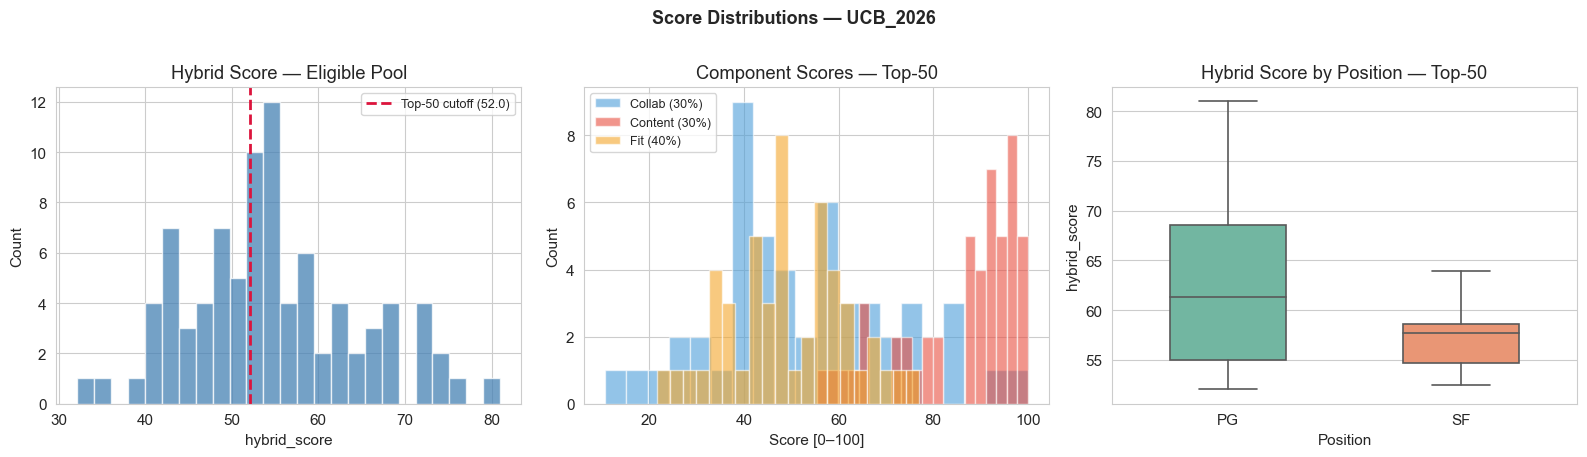

In [40]:
eligible_mask  = apply_position_filter(players, program)
all_eligible   = players[eligible_mask]
top50_cutoff   = top50['hybrid_score'].min()

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
fig.suptitle(f'Score Distributions — {program["program_id"]}', fontsize=13, fontweight='bold', y=1.01)

# --- Panel 1: Hybrid score distribution + top-50 cutoff ---
axes[0].hist(all_eligible['hybrid_score'], bins=25, color='steelblue', alpha=0.75, edgecolor='white')
axes[0].axvline(top50_cutoff, color='crimson', lw=2, ls='--',
                label=f'Top-50 cutoff ({top50_cutoff:.1f})')
axes[0].set_title('Hybrid Score — Eligible Pool')
axes[0].set_xlabel('hybrid_score')
axes[0].set_ylabel('Count')
axes[0].legend(fontsize=9)

# --- Panel 2: Component scores for top-50 ---
comp_colors = ['#4C9ED9', '#E84E40', '#F4A62A']
comp_labels = ['collab_score', 'content_score', 'overall_fit']
comp_names  = ['Collab (30%)', 'Content (30%)', 'Fit (40%)']
for col, color, label in zip(comp_labels, comp_colors, comp_names):
    axes[1].hist(top50[col], bins=20, alpha=0.6, color=color, label=label, edgecolor='white')
axes[1].set_title('Component Scores — Top-50')
axes[1].set_xlabel('Score [0–100]')
axes[1].set_ylabel('Count')
axes[1].legend(fontsize=9)

# --- Panel 3: Hybrid score by position (top-50) ---
pos_order = sorted(top50['position'].unique())
sns.boxplot(
    data=top50, x='position', y='hybrid_score',
    order=pos_order, palette='Set2', ax=axes[2],
    width=0.5, linewidth=1.2,
)
axes[2].set_title('Hybrid Score by Position — Top-50')
axes[2].set_xlabel('Position')
axes[2].set_ylabel('hybrid_score')

plt.tight_layout()
plt.show()

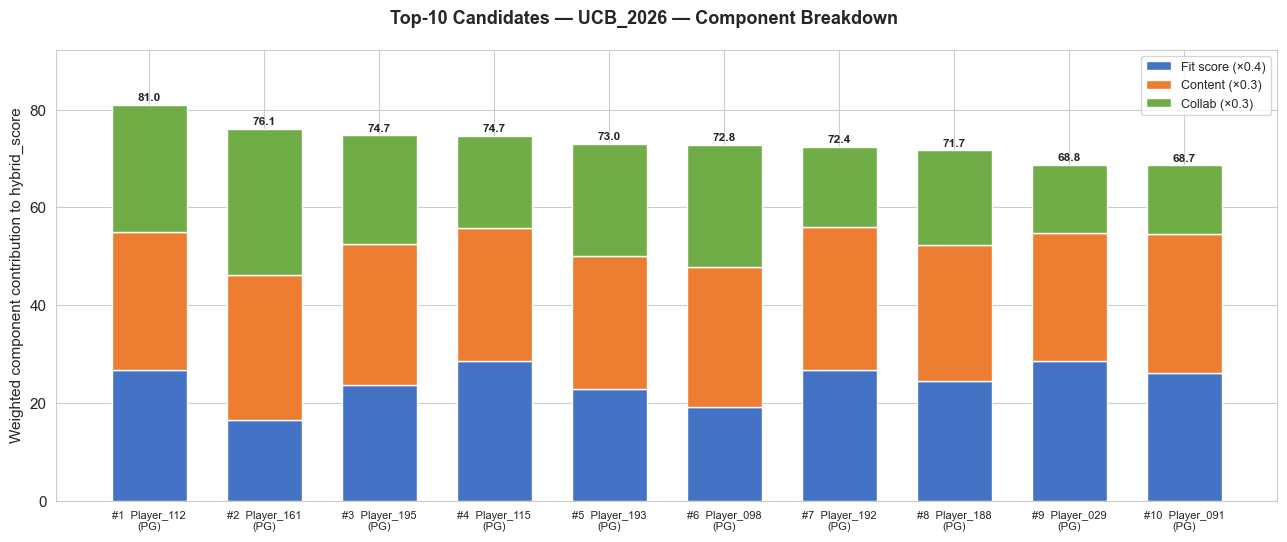

In [41]:
top10 = top50.head(10).copy()

fig, ax = plt.subplots(figsize=(13, 5.5))
fig.suptitle(f'Top-10 Candidates — {program["program_id"]} — Component Breakdown',
             fontsize=13, fontweight='bold')

x     = np.arange(len(top10))
bar_w = 0.65

# Weighted contribution of each component to hybrid_score
c_fit     = (top10['overall_fit'].values   * W_FIT)
c_content = (top10['content_score'].values * W_CONTENT)
c_collab  = (top10['collab_score'].values  * W_COLLAB)

ax.bar(x, c_fit,     bar_w, label=f'Fit score (×{W_FIT})',     color='#4472C4')
ax.bar(x, c_content, bar_w, bottom=c_fit,
       label=f'Content (×{W_CONTENT})',  color='#ED7D31')
ax.bar(x, c_collab,  bar_w, bottom=c_fit + c_content,
       label=f'Collab (×{W_COLLAB})',   color='#70AD47')

# Annotate total hybrid_score on top of each bar
for i, hs in enumerate(top10['hybrid_score'].values):
    ax.text(i, hs + 0.4, f'{hs:.1f}', ha='center', va='bottom', fontsize=8.5, fontweight='bold')

tick_labels = [
    f'#{int(r["rank"])}  {r["name"]}\n({r["position"]})'
    for _, r in top10.iterrows()
]
ax.set_xticks(x)
ax.set_xticklabels(tick_labels, fontsize=8)
ax.set_ylabel('Weighted component contribution to hybrid_score')
ax.set_ylim(0, top10['hybrid_score'].max() * 1.14)
ax.legend(loc='upper right', fontsize=9)

plt.tight_layout()
plt.show()

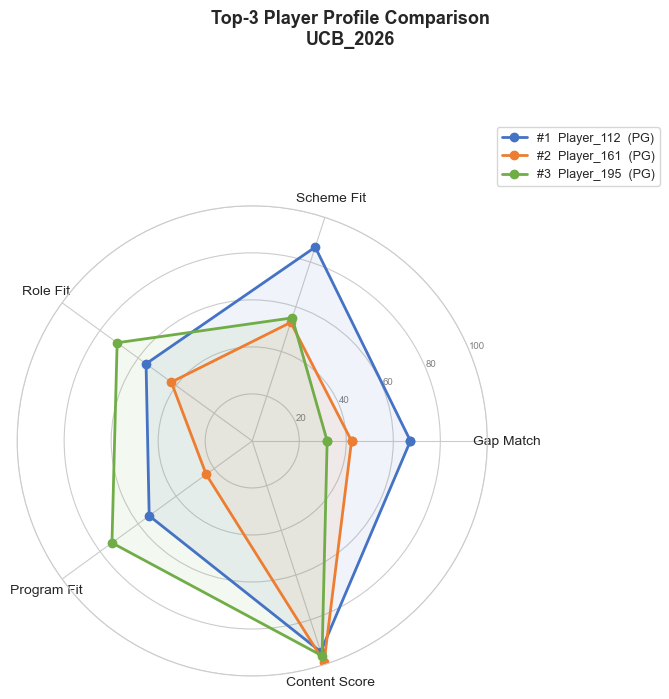

In [42]:
# 5 dimensions on the radar: four fit sub-scores + content_score
RADAR_DIMS   = ['gap_match', 'scheme_fit', 'role_fit', 'program_fit', 'content_score']
RADAR_LABELS = ['Gap Match', 'Scheme Fit', 'Role Fit', 'Program Fit', 'Content Score']

top3   = top50.head(3)
n_dims = len(RADAR_DIMS)
angles = np.linspace(0, 2 * np.pi, n_dims, endpoint=False).tolist()
angles += angles[:1]   # close the polygon

colors = ['#4472C4', '#ED7D31', '#70AD47']

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw={'projection': 'polar'})
fig.suptitle(f'Top-3 Player Profile Comparison\n{program["program_id"]}',
             fontsize=13, fontweight='bold', y=1.02)

for (_, row), color in zip(top3.iterrows(), colors):
    values = [row[d] for d in RADAR_DIMS] + [row[RADAR_DIMS[0]]]  # close
    label  = f'#{int(row["rank"])}  {row["name"]}  ({row["position"]})'
    ax.plot(angles, values, 'o-', lw=2.0, color=color, label=label)
    ax.fill(angles, values, alpha=0.08, color=color)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(RADAR_LABELS, fontsize=10)
ax.set_ylim(0, 100)
ax.set_yticks([20, 40, 60, 80, 100])
ax.set_yticklabels(['20', '40', '60', '80', '100'], fontsize=7, color='grey')
ax.legend(loc='upper right', bbox_to_anchor=(1.38, 1.18), fontsize=9)

plt.tight_layout()
plt.show()